<div style="text-align: center; padding: 30px 0;">

# 🎓 Learning Behavior Clustering and Student Profiling
## Phase 2 — K-Means Clustering & Cluster Analysis

</div>

---
## 1. Introduction

This notebook presents **Phase 2** of the *Learning Behavior Clustering and Student Profiling* project: **K-Means clustering and cluster interpretation**.

### Objective

Using the cleaned dataset from Phase 1, this analysis aims to:
1. Determine an appropriate number of clusters using Elbow, Silhouette, and Davies-Bouldin criteria.
2. Train a K-Means model to group students by learning behavior and performance.
3. Interpret cluster profiles for academic support planning.
4. Identify at-risk students for early intervention.
5. Assess clustering stability across repeated subsamples.

### Rationale for K-Means

K-Means is selected because it is computationally efficient, scalable to large cohorts, and produces interpretable centroid-based profiles suitable for advising use cases.

---
## 2. Setup & Imports

We import all necessary libraries for data manipulation, visualization, clustering, and evaluation.

In [28]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
from pathlib import Path

# ── Data manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: Clustering, Metrics, Preprocessing, Dimensionality Reduction ─
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# ── Global settings ───────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Consistent plot style
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

np.random.seed(42)  # Reproducibility

print(" All libraries imported successfully.")
print(f"   pandas    {pd.__version__}")
print(f"   numpy     {np.__version__}")
print(f"   sklearn   {__import__('sklearn').__version__}")

 All libraries imported successfully.
   pandas    2.2.3
   numpy     1.26.4
   sklearn   1.7.1


---
## 3. Load the Cleaned Dataset

Load the processed dataset from Phase 1 (Data Collection & Preprocessing).

In [29]:
# ── File paths ────────────────────────────────────────────────────────────────
PROCESSED_DATA_PATH = Path("../Data/processed/cleaned_dataset.csv")

# ── Load the cleaned dataset ──────────────────────────────────────────────────
df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"✅ Cleaned dataset loaded.")
print(f"   Path  : {PROCESSED_DATA_PATH}")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📌 Columns (features):")
print(df.columns.tolist())

✅ Cleaned dataset loaded.
   Path  : ..\Data\processed\cleaned_dataset.csv
   Shape : 12,469 rows × 16 columns

📌 Columns (features):
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


---
## 4. Feature Selection & Final Preprocessing for Clustering

### Feature Selection Strategy

The feature set was chosen to represent study behavior, engagement, access to learning resources, and academic outcomes. Distance-based clustering is sensitive to feature quality, so non-informative or unsuitable variables were excluded.

| Feature | Justification |
|---------|---------------|
| **StudyHours** | Learning effort |
| **Attendance** | Class engagement |
| **Resources** | Access to support |
| **Extracurricular** | Broader engagement |
| **AssignmentCompletion** | Academic consistency |
| **ExamScore** | Direct performance measure |
| **OnlineCourses** | Self-directed learning |
| **Motivation** | Behavioral driver |
| **Internet** | Digital access |
| **Discussions** | Participation level |
| **EduTech** | Use of learning tools |
| **StressLevel** | Academic pressure indicator |
| **Age** | Maturity proxy |
| **FinalGrade** | Overall outcome |

### Excluded Features

- **`Gender`**: excluded to avoid demographic-driven segmentation and because categorical distance is not naturally meaningful in Euclidean space.
- **`LearningStyle`**: excluded because direct category encoding can introduce artificial distances.

### Why StandardScaler?

K-Means uses Euclidean distance. Standardization is required so variables on larger numeric ranges do not dominate distance calculations.

In [30]:
# ── Select clustering features ────────────────────────────────────────────────
CLUSTERING_FEATURES = [
    "StudyHours",
    "Attendance",
    "Resources",
    "Extracurricular",
    "Motivation",
    "Internet",
    "Age",
    "OnlineCourses",
    "Discussions",
    "AssignmentCompletion",
    "ExamScore",
    "EduTech",
    "StressLevel",
    "FinalGrade",
]

print(f"📌 Selected {len(CLUSTERING_FEATURES)} features for clustering:")
for i, feat in enumerate(CLUSTERING_FEATURES, 1):
    print(f"   {i}. {feat}")

# ── Extract feature matrix ────────────────────────────────────────────────────
X = df[CLUSTERING_FEATURES].copy()
print(f"\n✅ Feature matrix shape: {X.shape}")

📌 Selected 14 features for clustering:
   1. StudyHours
   2. Attendance
   3. Resources
   4. Extracurricular
   5. Motivation
   6. Internet
   7. Age
   8. OnlineCourses
   9. Discussions
   10. AssignmentCompletion
   11. ExamScore
   12. EduTech
   13. StressLevel
   14. FinalGrade

✅ Feature matrix shape: (12469, 14)


In [31]:
# ── Check for missing values ─────────────────────────────────────────────────
missing = X.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values in clustering features.")
else:
    print(f"⚠️  Missing values detected:\n{missing[missing > 0]}")
    X.fillna(X.median(), inplace=True)
    print("   → Imputed with median values.")

✅ No missing values in clustering features.


In [32]:
# ── Apply StandardScaler for normalization ────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for easier interpretation later
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=CLUSTERING_FEATURES,
    index=df.index
)

print("✅ StandardScaler applied.")
print(f"   Scaled features shape: {X_scaled.shape}")
print(f"\n📌 Scaled data summary (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(4))

✅ StandardScaler applied.
   Scaled features shape: (12469, 14)

📌 Scaled data summary (mean ≈ 0, std ≈ 1):
       StudyHours  Attendance  Resources  Extracurricular  Motivation  \
count  12469.0000  12469.0000 12469.0000       12469.0000  12469.0000   
mean      -0.0000      0.0000    -0.0000          -0.0000      0.0000   
std        1.0000      1.0000     1.0000           1.0000      1.0000   
min       -2.4948     -1.7648    -1.5487          -1.1827     -1.2788   
25%       -0.6685     -0.8928    -0.1425          -1.1827     -1.2788   
50%       -0.0040     -0.0209    -0.1425           0.8455      0.1305   
75%        0.6599      0.8511     1.2636           0.8455      0.1305   
max        2.6524      1.7230     1.2636           0.8455      1.5398   

        Internet        Age  OnlineCourses  Discussions  AssignmentCompletion  \
count 12469.0000 12469.0000     12469.0000   12469.0000            12469.0000   
mean     -0.0000     0.0000         0.0000      -0.0000               -0

---
## 5. Choosing the Optimal Number of Clusters (k)

Determining the optimal k is critical. We apply **three complementary methods**:

### 5.1 Elbow Method (WCSS)
Plots **Within-Cluster Sum of Squares (WCSS)** vs. k. The "elbow" point represents where adding more clusters yields diminishing improvements.

### 5.2 Silhouette Score
Measures how similar a sample is to its own cluster vs. other clusters. Range: [-1, 1]. Higher is better.

### 5.3 Davies-Bouldin Index (DBI)
Ratio of within-cluster to between-cluster distances. **Lower is better**. DBI < 1 indicates well-separated clusters.

In [33]:
# ── Compute WCSS, Silhouette, and DBI for k = 2 to 10 ──────────────────────────
k_range = range(2, 11)
wcss_list = []
silhouette_list = []
dbi_list = []

print("🔄 Computing metrics for k = 2 to 10...")

for k in k_range:
    # Train KMeans
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    labels = kmeans.fit_predict(X_scaled)
    
    # Compute metrics
    wcss = kmeans.inertia_
    sil_score = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)
    
    wcss_list.append(wcss)
    silhouette_list.append(sil_score)
    dbi_list.append(dbi)
    
    print(f"   k={k}  │  WCSS={wcss:.2f}  │  Silhouette={sil_score:.4f}  │  DBI={dbi:.4f}")

print("\n✅ Metrics computed.")

🔄 Computing metrics for k = 2 to 10...
   k=2  │  WCSS=155154.81  │  Silhouette=0.1072  │  DBI=2.7888
   k=3  │  WCSS=144174.75  │  Silhouette=0.1182  │  DBI=2.3905
   k=4  │  WCSS=138359.08  │  Silhouette=0.0926  │  DBI=2.6062
   k=5  │  WCSS=132772.71  │  Silhouette=0.0857  │  DBI=2.8560
   k=6  │  WCSS=128698.01  │  Silhouette=0.0825  │  DBI=2.7642
   k=7  │  WCSS=125994.02  │  Silhouette=0.0763  │  DBI=2.8427
   k=8  │  WCSS=122397.35  │  Silhouette=0.0776  │  DBI=2.6491
   k=9  │  WCSS=120589.93  │  Silhouette=0.0730  │  DBI=2.6610
   k=10  │  WCSS=118839.23  │  Silhouette=0.0748  │  DBI=2.7632

✅ Metrics computed.


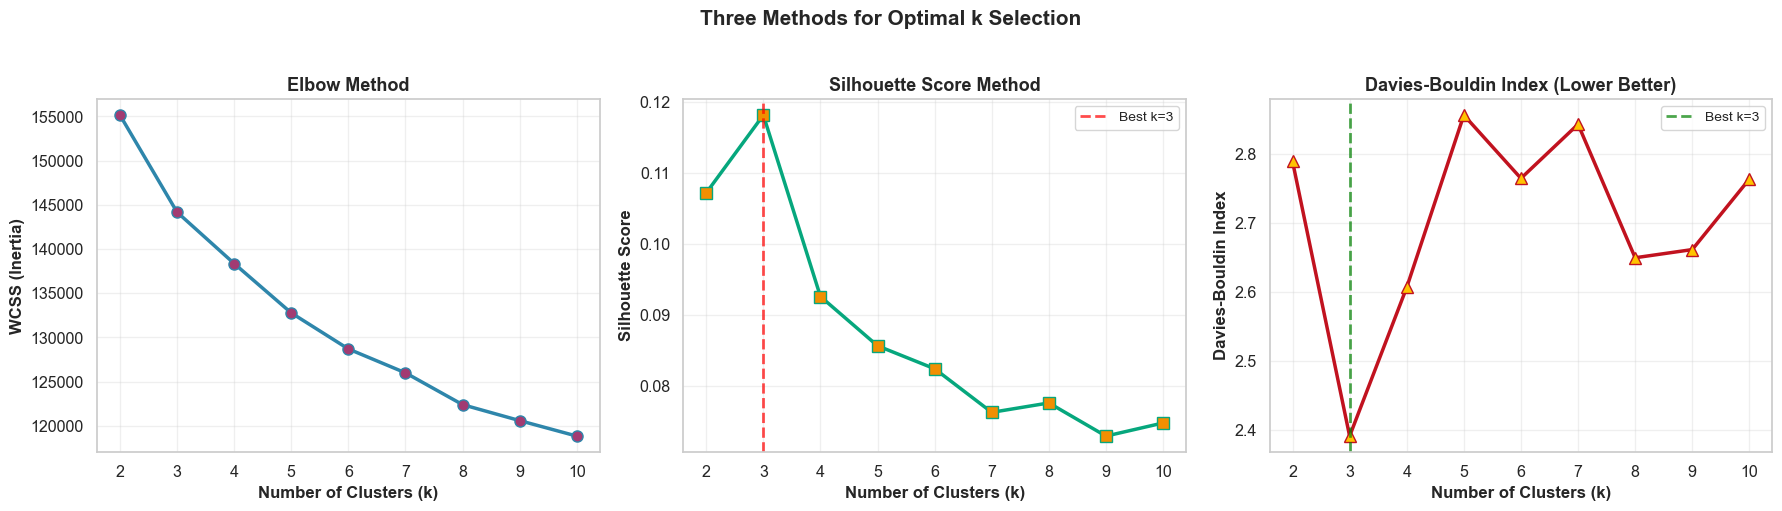

📌 Best k by Silhouette Score: 3
📌 Best k by Davies-Bouldin Index: 3


In [34]:
# ── Plot the three methods side by side ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Method
axes[0].plot(k_range, wcss_list, marker='o', linestyle='-', linewidth=2.5,
             markersize=8, color='#2E86AB', markerfacecolor='#A23B72')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Silhouette Score
axes[1].plot(k_range, silhouette_list, marker='s', linestyle='-', linewidth=2.5,
             markersize=8, color='#06A77D', markerfacecolor='#F18F01')
best_sil_k = k_range[np.argmax(silhouette_list)]
axes[1].axvline(x=best_sil_k, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Best k={best_sil_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score Method', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)
axes[1].legend(fontsize=10)

# Davies-Bouldin Index
axes[2].plot(k_range, dbi_list, marker='^', linestyle='-', linewidth=2.5,
             markersize=8, color='#C1121F', markerfacecolor='#FFC300')
best_dbi_k = k_range[np.argmin(dbi_list)]
axes[2].axvline(x=best_dbi_k, color='green', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Best k={best_dbi_k}')
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
axes[2].set_title('Davies-Bouldin Index (Lower Better)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_range)
axes[2].legend(fontsize=10)

plt.suptitle('Three Methods for Optimal k Selection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"📌 Best k by Silhouette Score: {best_sil_k}")
print(f"📌 Best k by Davies-Bouldin Index: {best_dbi_k}")

### 5.4 Decision: Optimal k

Summary of criteria:
- **Elbow** suggests diminishing returns after approximately `k=3` to `k=4`.
- **Silhouette** is maximized at `k=3`.
- **Davies-Bouldin** is minimized at `k=3`.

**Final choice: `k=3`**.

This value provides the strongest internal-metric support in the current pipeline while preserving practical interpretability for student profiling.

In [35]:
# ── Set the optimal k ─────────────────────────────────────────────────────────
# Based on the methods above, we choose:
OPTIMAL_K = 3

print(f"🎯 Optimal number of clusters selected: {OPTIMAL_K}")
print(f"   Silhouette Score at k={OPTIMAL_K}: {silhouette_list[OPTIMAL_K - 2]:.4f}")
print(f"   Davies-Bouldin Index at k={OPTIMAL_K}: {dbi_list[OPTIMAL_K - 2]:.4f}")

🎯 Optimal number of clusters selected: 3
   Silhouette Score at k=3: 0.1182
   Davies-Bouldin Index at k=3: 2.3905


---
## 6. Train the Final K-Means Model

Train the final K-Means model with the selected optimal k.

In [36]:
# ── Train final KMeans model ──────────────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10,
    max_iter=300
)

df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"✅ Final K-Means model trained with k={OPTIMAL_K}")
print(f"   Converged: True")
print(f"   Inertia: {kmeans_final.inertia_:.2f}")

✅ Final K-Means model trained with k=3
   Converged: True
   Inertia: 144174.75


In [48]:
# ── Cluster distribution ──────────────────────────────────────────────────────
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / len(df) * 100).round(2)

print(f"\n📌 Distribution of students across clusters:\n")
for cluster_id in sorted(df['Cluster'].unique()):
    count = cluster_counts[cluster_id]
    pct = cluster_pct[cluster_id]
    print(f"   Cluster {cluster_id}: {count:>5,} students ({pct:>6}%)")

print(f"\n   Total: {len(df):>5,} students (100.00%)")


📌 Distribution of students across clusters:

   Cluster 0: 1,034 students (  8.29%)
   Cluster 1: 5,794 students ( 46.47%)
   Cluster 2: 5,641 students ( 45.24%)

   Total: 12,469 students (100.00%)


---
## 7. Cluster Evaluation

Evaluate the final model using three complementary metrics:

- **Silhouette Score**: Measures cluster cohesion and separation. Range [-1, 1]; higher is better.
- **Davies-Bouldin Index**: Ratio of average similarity within clusters to between clusters. Lower is better.
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster dispersion. Higher is better.

In [37]:
# ── Compute evaluation metrics ────────────────────────────────────────────────
sil_score = silhouette_score(X_scaled, df['Cluster'])
dbi = davies_bouldin_score(X_scaled, df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])

print("\n" + "="*70)
print(f"  CLUSTER EVALUATION METRICS (k={OPTIMAL_K})")
print("="*70)
print(f"\n  📊 Silhouette Score: {sil_score:.4f}")
print(f"     Range: [-1, 1]  │  Target: > 0.5 (good), > 0.7 (excellent)")
if sil_score > 0.7:
    print(f"     ✅ EXCELLENT cluster separation and cohesion.")
elif sil_score > 0.5:
    print(f"     ✅ GOOD cluster separation and cohesion.")
elif sil_score > 0.25:
    print(f"     ⚠️  MODERATE clustering quality; some overlap expected.")
else:
    print(f"     ❌ WEAK clustering; consider re-evaluating k.")

print(f"\n  📊 Davies-Bouldin Index: {dbi:.4f}")
print(f"     Range: [0, ∞)  │  Target: < 1.0 (good)")
if dbi < 1.0:
    print(f"     ✅ Well-separated clusters.")
elif dbi < 1.5:
    print(f"     ⚠️  Moderate separation; some cluster overlap.")
else:
    print(f"     ❌ Poor separation; clusters are overlapping.")

print(f"\n  📊 Calinski-Harabasz Score: {ch_score:.4f}")
print(f"     Range: [0, ∞)  │  Target: > 500 (reasonable), > 1000 (good)")
if ch_score > 1000:
    print(f"     ✅ Excellent cluster definition.")
elif ch_score > 500:
    print(f"     ✅ Good cluster definition.")
else:
    print(f"     ⚠️  Clusters may not be well-defined.")

print("\n" + "="*70)


  CLUSTER EVALUATION METRICS (k=3)

  📊 Silhouette Score: 0.1182
     Range: [-1, 1]  │  Target: > 0.5 (good), > 0.7 (excellent)
     ❌ WEAK clustering; consider re-evaluating k.

  📊 Davies-Bouldin Index: 2.3905
     Range: [0, ∞)  │  Target: < 1.0 (good)
     ❌ Poor separation; clusters are overlapping.

  📊 Calinski-Harabasz Score: 1313.8822
     Range: [0, ∞)  │  Target: > 500 (reasonable), > 1000 (good)
     ✅ Excellent cluster definition.



### Interpretation Summary

The internal metrics indicate **usable but not perfectly separated clusters**:
- Silhouette and Davies-Bouldin indicate overlap between groups.
- Calinski-Harabasz indicates meaningful global structure.

Therefore, the model should be interpreted as a **practical segmentation tool** rather than a strict high-separation partition.

---
## 8. Cluster Visualization

### 8.1 PCA Visualization (2D)

Apply PCA (Principal Component Analysis) to reduce dimensions from 14 to 2 while preserving as much variance as possible. This allows us to visualize clusters in 2D space.

In [38]:
# ── Apply PCA ─────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA applied.")
print(f"   Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"   Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

✅ PCA applied.
   Explained variance ratio: [0.14123183 0.07646333]
   Total variance explained: 21.77%


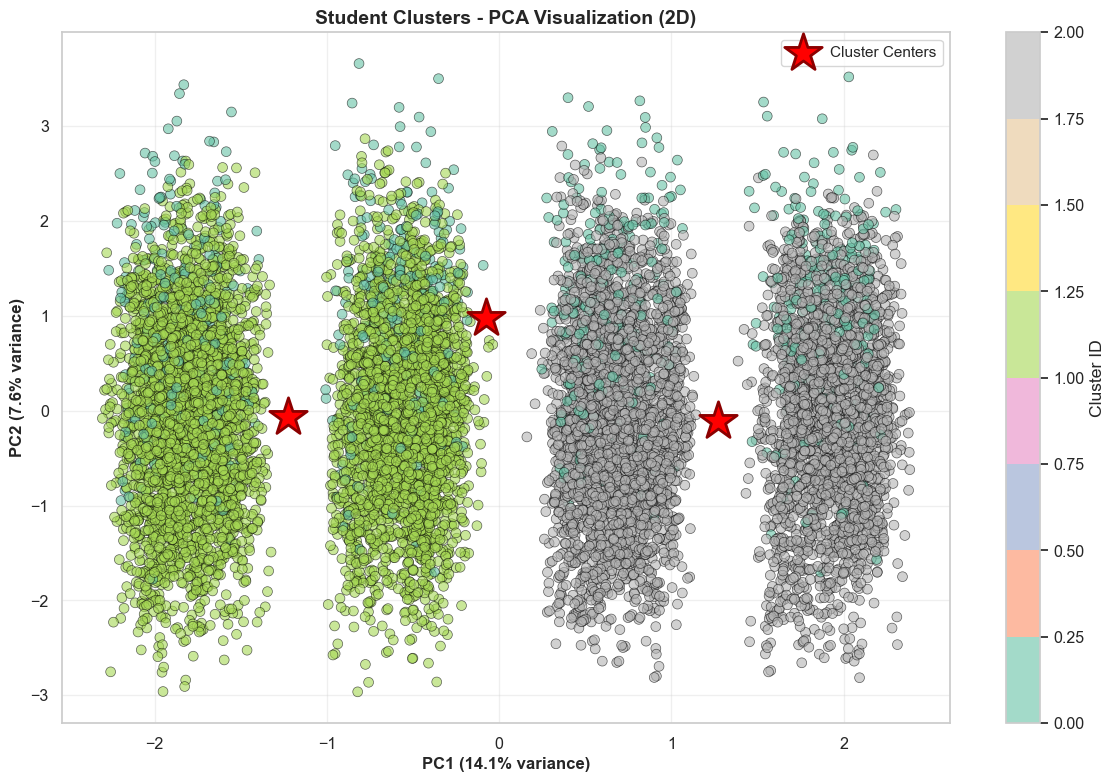

✅ PCA visualization complete.


In [39]:
# ── Plot clusters using PCA ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['Cluster'],
    cmap='Set2',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Plot cluster centers (transformed via PCA)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='red',
    marker='*',
    s=800,
    edgecolors='darkred',
    linewidth=2,
    label='Cluster Centers',
    zorder=5
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('Student Clusters - PCA Visualization (2D)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.show()

print("✅ PCA visualization complete.")

### 8.2 t-SNE Visualization (Non-linear)

Apply t-SNE (t-Distributed Stochastic Neighbor Embedding) for a non-linear dimensionality reduction. t-SNE often reveals cluster structure more clearly than PCA by preserving local neighborhood relationships.

In [40]:
# ── Apply t-SNE (with perplexity tuned for dataset size) ────────────────────
print("🔄 Computing t-SNE (this may take 30-60 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)
print("✅ t-SNE completed.")

🔄 Computing t-SNE (this may take 30-60 seconds)...
✅ t-SNE completed.


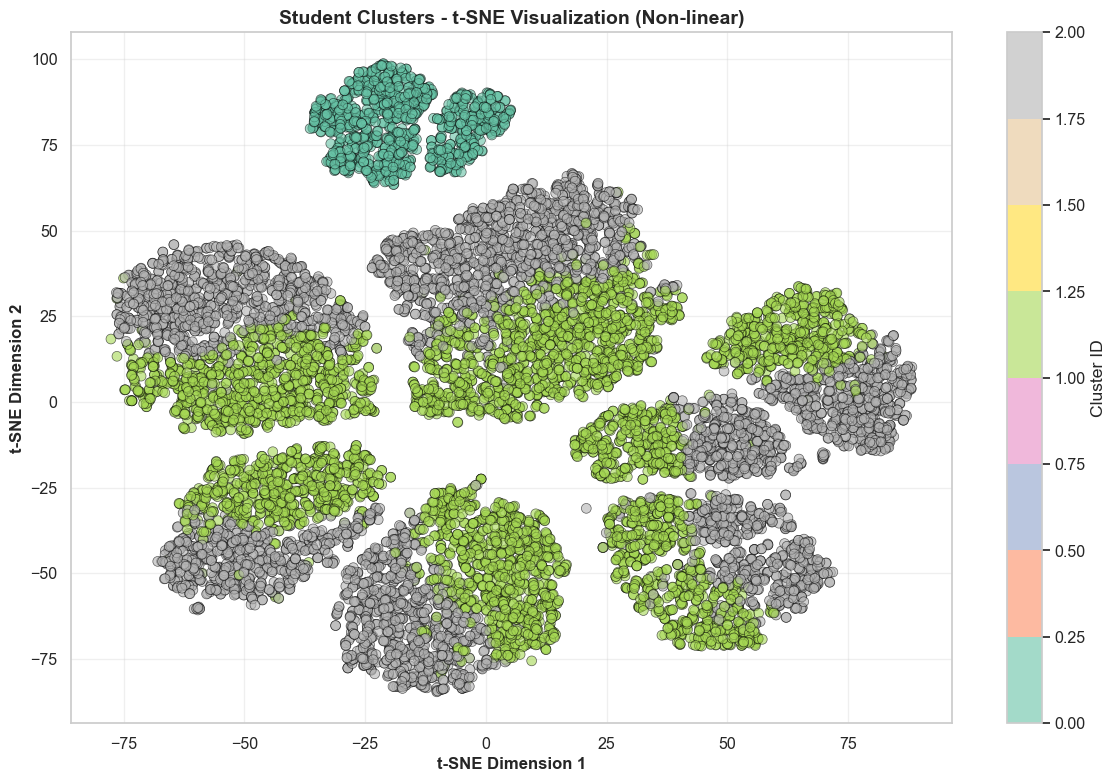

✅ t-SNE visualization complete.


In [41]:
# ── Plot clusters using t-SNE ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=df['Cluster'],
    cmap='Set2',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Student Clusters - t-SNE Visualization (Non-linear)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.show()

print("✅ t-SNE visualization complete.")

### 8.3 Feature Distributions by Cluster (Boxplots)

Display boxplots for key features grouped by cluster to understand how feature values differ across learning profiles.

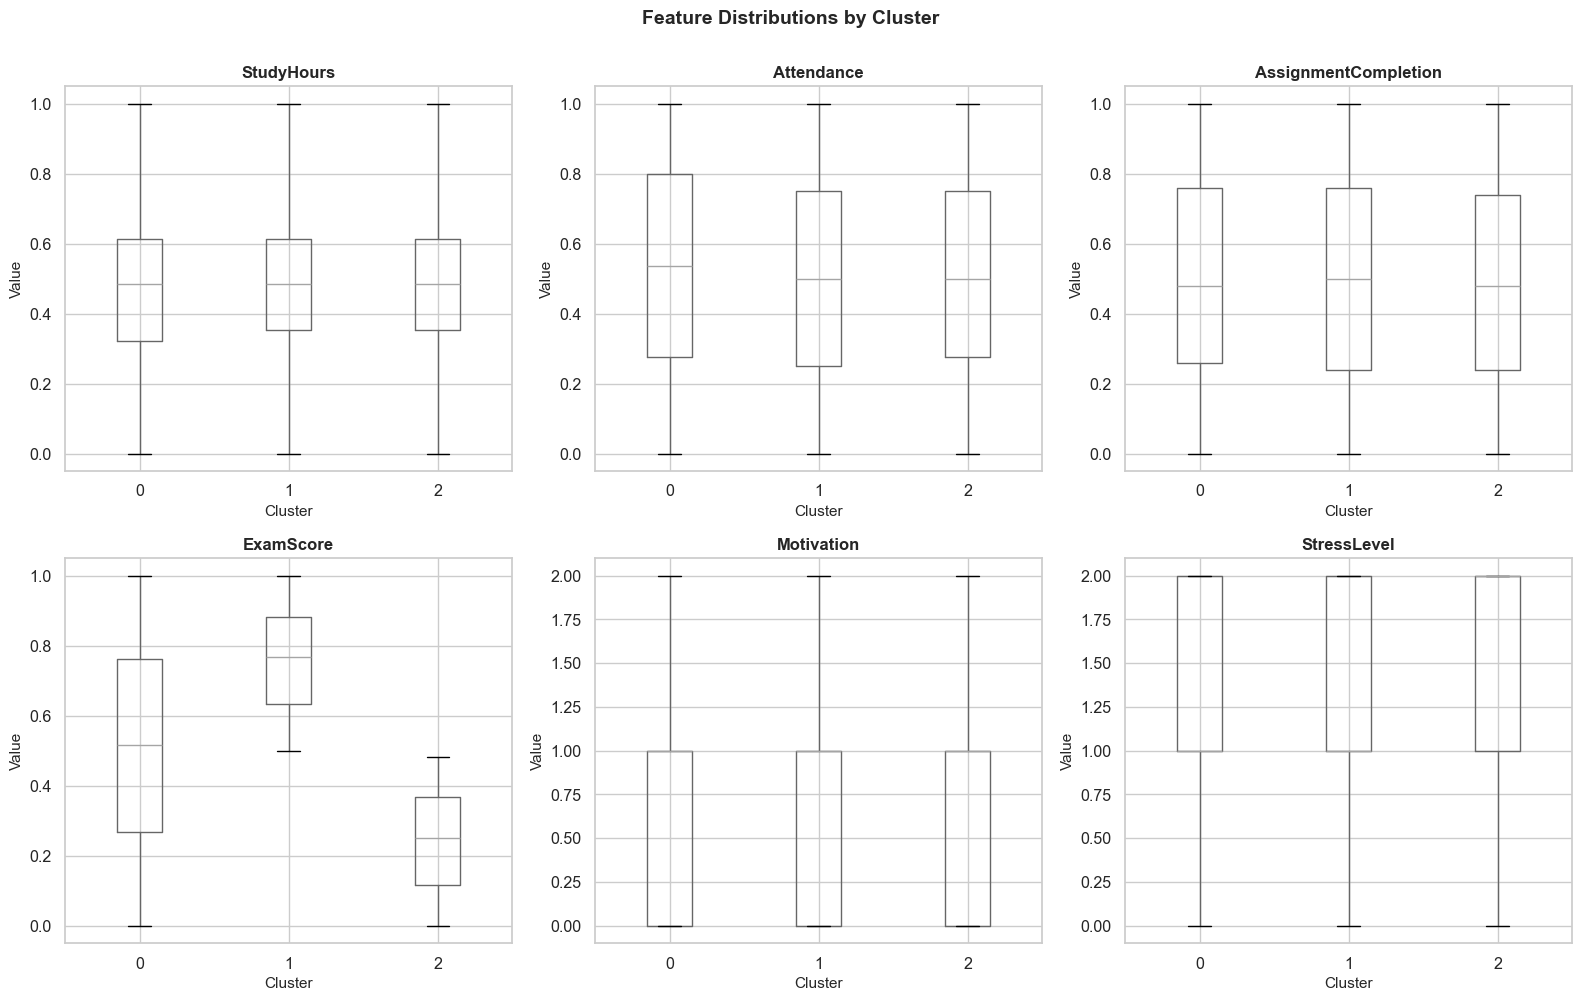

✅ Boxplot visualization complete.


In [42]:
# ── Boxplots for key features by cluster ──────────────────────────────────────
key_features = [
    "StudyHours",
    "Attendance",
    "AssignmentCompletion",
    "ExamScore",
    "Motivation",
    "StressLevel"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    df.boxplot(column=feature, by='Cluster', ax=axes[i])
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=11)
    axes[i].set_ylabel('Value', fontsize=11)
    axes[i].get_figure().suptitle('')  # Remove automatic title

plt.suptitle('Feature Distributions by Cluster', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Boxplot visualization complete.")

### 8.4 Cluster Profiles - Radar Chart

Display average feature values per cluster in a radar (spider) chart for intuitive comparison across all features simultaneously.

In [43]:
# ── Compute mean values per cluster (in original scale) ──────────────────────
cluster_profiles = df.groupby('Cluster')[CLUSTERING_FEATURES].mean()

print("📌 Cluster Profiles (Mean Values):")
print(cluster_profiles.round(3))

📌 Cluster Profiles (Mean Values):
         StudyHours  Attendance  Resources  Extracurricular  Motivation  \
Cluster                                                                   
0            0.4800      0.5310     1.1610           0.6230      0.8790   
1            0.4870      0.5060     1.1000           0.5800      0.9050   
2            0.4840      0.5020     1.0920           0.5790      0.9150   

         Internet    Age  OnlineCourses  Discussions  AssignmentCompletion  \
Cluster                                                                      
0          0.0000 0.5060         0.4960       0.6170                0.4970   
1          1.0000 0.4970         0.4980       0.5910                0.4970   
2          1.0000 0.5070         0.4880       0.6200                0.4820   

         ExamScore  EduTech  StressLevel  FinalGrade  
Cluster                                               
0           0.5120   0.7000       1.3130      1.4170  
1           0.7570   0.7120       

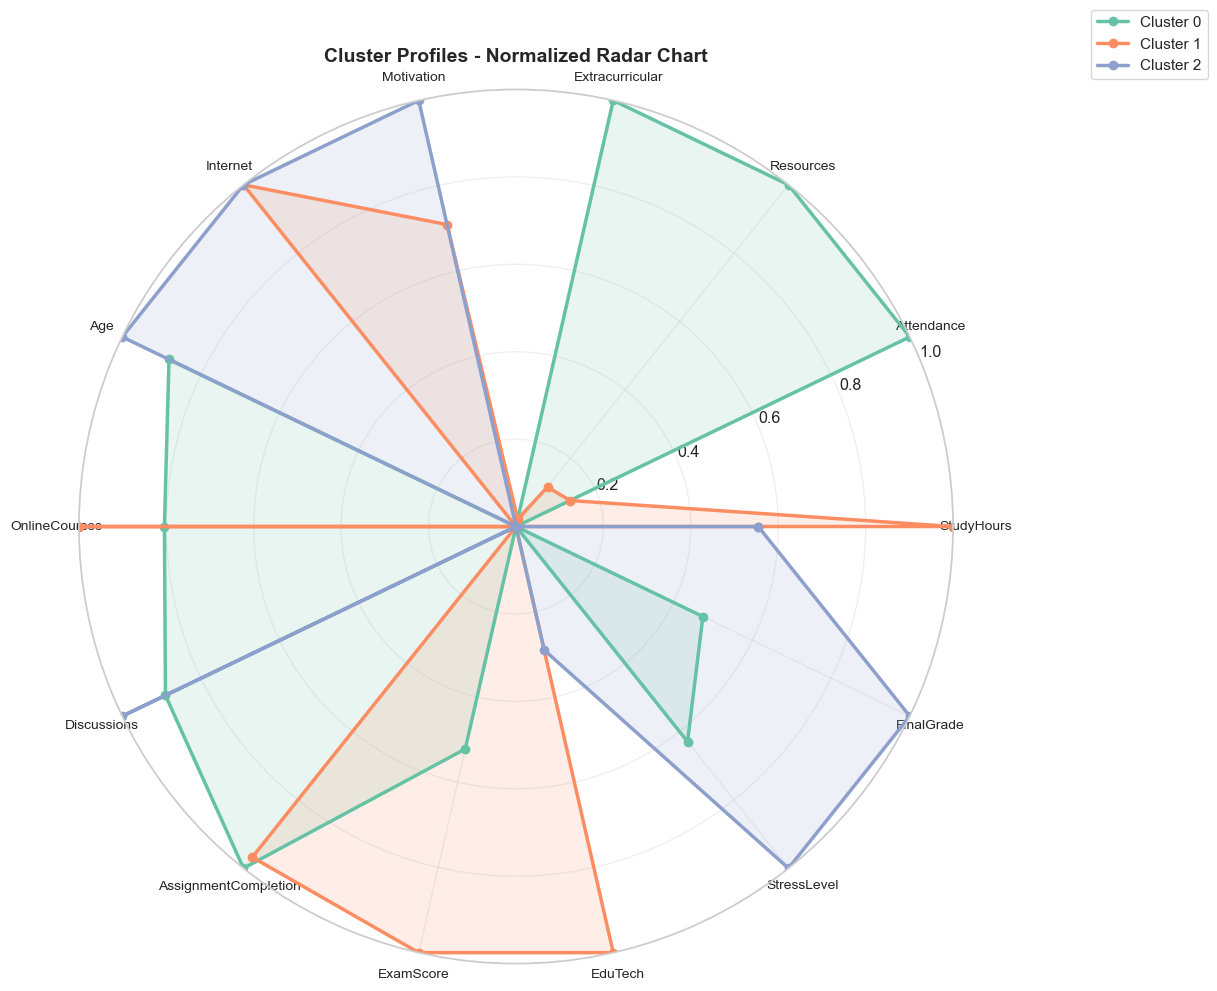

✅ Radar chart visualization complete.


In [44]:
# ── Radar chart for cluster profiles ──────────────────────────────────────────
from math import pi

# Normalize profiles for radar chart (scale 0-1 for visibility)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min()
)

categories = list(cluster_profiles_norm.columns)
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

colors = sns.color_palette('Set2', OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    values = cluster_profiles_norm.loc[cluster_id].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2.5, label=f'Cluster {cluster_id}',
            color=colors[cluster_id])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('Cluster Profiles - Normalized Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Radar chart visualization complete.")

---
## 9. Cluster Profiling & Interpretation

Analyze the characteristics of each cluster and assign meaningful educational profile labels.

In [45]:
# ── Centroid analysis (inverse transform to original scale) ──────────────────
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=CLUSTERING_FEATURES)

print("\n" + "="*100)
print("  CLUSTER CENTROID VALUES (Original Scale)")
print("="*100)
print(centroids_df.round(3))
print("="*100)


  CLUSTER CENTROID VALUES (Original Scale)
   StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0      0.4800      0.5310     1.1610           0.6230      0.8790    0.0000   
1      0.4870      0.5060     1.1000           0.5800      0.9050    1.0000   
2      0.4840      0.5020     1.0920           0.5790      0.9150    1.0000   

     Age  OnlineCourses  Discussions  AssignmentCompletion  ExamScore  \
0 0.5060         0.4960       0.6170                0.4970     0.5120   
1 0.4970         0.4980       0.5910                0.4970     0.7570   
2 0.5070         0.4880       0.6200                0.4820     0.2450   

   EduTech  StressLevel  FinalGrade  
0   0.7000       1.3130      1.4170  
1   0.7120       1.2730      0.4610  
2   0.7040       1.3370      2.4750  


In [46]:
# ── Cluster labeling based on characteristic profiles ───────────────────────
# Rank clusters by exam performance and assign three interpretable labels

cluster_labels = {}
cluster_descriptions = {}

ranked_cluster_ids = centroids_df['ExamScore'].sort_values(ascending=False).index.tolist()
high_perf_cluster = ranked_cluster_ids[0]
at_risk_cluster = ranked_cluster_ids[-1]
middle_clusters = [cluster_id for cluster_id in ranked_cluster_ids if cluster_id not in [high_perf_cluster, at_risk_cluster]]

cluster_labels[high_perf_cluster] = "🟢 High Performers"
cluster_descriptions[high_perf_cluster] = "Dedicated, consistent, and high-achieving students with strong academic engagement."

cluster_labels[at_risk_cluster] = "🔴 At-Risk / Struggling Students"
cluster_descriptions[at_risk_cluster] = "Lowest-performing cluster; students here need early support and intervention."

for cluster_id in middle_clusters:
    cluster_labels[cluster_id] = "🟡 Average / Steady Learners"
    cluster_descriptions[cluster_id] = "Balanced students with moderate outcomes and room for improvement."

# Display cluster profiles with labels
print("\n" + "#"*100)
print("  CLUSTER PROFILES & INTERPRETATIONS")
print("#"*100)

# Display clusters from strongest to weakest by exam score
sorted_cluster_ids = ranked_cluster_ids


for cluster_id in sorted_cluster_ids:
    count = (df['Cluster'] == cluster_id).sum()
    pct = (count / len(df) * 100)
    
    print(f"\n{cluster_labels[cluster_id]}")
    print(f"{'─' * 100}")
    print(f"Cluster ID: {cluster_id}  │  Size: {count:,} students ({pct:.1f}% of cohort)")
    print(f"\n{cluster_descriptions[cluster_id]}")
    print(f"\nKey Metrics:")
    
    centroid = centroids_df.loc[cluster_id]
    for feature in CLUSTERING_FEATURES:
        print(f"   • {feature:.<25} {centroid[feature]:>8.2f}")

print(f"\n{'#'*100}")


####################################################################################################
  CLUSTER PROFILES & INTERPRETATIONS
####################################################################################################

🟢 High Performers
────────────────────────────────────────────────────────────────────────────────────────────────────
Cluster ID: 1  │  Size: 5,794 students (46.5% of cohort)

Dedicated, consistent, and high-achieving students with strong academic engagement.

Key Metrics:
   • StudyHours...............     0.49
   • Attendance...............     0.51
   • Resources................     1.10
   • Extracurricular..........     0.58
   • Motivation...............     0.90
   • Internet.................     1.00
   • Age......................     0.50
   • OnlineCourses............     0.50
   • Discussions..............     0.59
   • AssignmentCompletion.....     0.50
   • ExamScore................     0.76
   • EduTech..................     0.71
   •

---
## 10. At-Risk Student Identification

Identify students in the "Struggling" or "At-Risk" cluster(s) for early intervention programs.

In [47]:
# ── Identify at-risk cluster ─────────────────────────────────────────────────
# Here we define at-risk as the cluster with the lowest centroid exam score

centroid_exam_scores = centroids_df['ExamScore'].values
at_risk_cluster_id = np.argmin(centroid_exam_scores)

at_risk_students = df[df['Cluster'] == at_risk_cluster_id].copy()

print(f"\n📌 At-Risk Cluster: Cluster {at_risk_cluster_id} ({cluster_labels[at_risk_cluster_id]})")
print(f"   Total at-risk students: {len(at_risk_students):,} ({len(at_risk_students) / len(df) * 100:.1f}%)")
print(f"\n📋 Sample of At-Risk Students (first 20):")
print(at_risk_students[CLUSTERING_FEATURES].head(20).round(2))


📌 At-Risk Cluster: Cluster 2 (🔴 At-Risk / Struggling Students)
   Total at-risk students: 5,641 (45.2%)

📋 Sample of At-Risk Students (first 20):
    StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0       0.4500      0.1000          1                0           0         1   
1       0.4500      0.1000          1                0           0         1   
3       0.4500      0.1000          1                1           0         1   
4       0.4500      0.1000          1                1           0         1   
6       0.4500      0.1000          0                1           0         1   
7       0.4500      0.1000          0                1           0         1   
9       0.4500      0.1000          1                1           1         1   
10      0.4500      0.1000          1                1           1         1   
12      0.4500      0.1000          2                0           1         1   
13      0.4500      0.1000          2                

In [49]:
# ── Summary statistics for at-risk students ──────────────────────────────────
print(f"\n📊 At-Risk Students - Summary Statistics:")
print(at_risk_students[CLUSTERING_FEATURES].describe().round(2))


📊 At-Risk Students - Summary Statistics:
       StudyHours  Attendance  Resources  Extracurricular  Motivation  \
count   5641.0000   5641.0000  5641.0000        5641.0000   5641.0000   
mean       0.4800      0.5000     1.0900           0.5800      0.9200   
std        0.1900      0.2800     0.7100           0.4900      0.7200   
min        0.0000      0.0000     0.0000           0.0000      0.0000   
25%        0.3500      0.2800     1.0000           0.0000      0.0000   
50%        0.4800      0.5000     1.0000           1.0000      1.0000   
75%        0.6100      0.7500     2.0000           1.0000      1.0000   
max        1.0000      1.0000     2.0000           1.0000      2.0000   

       Internet       Age  OnlineCourses  Discussions  AssignmentCompletion  \
count 5641.0000 5641.0000      5641.0000    5641.0000             5641.0000   
mean     1.0000    0.5100         0.4900       0.6200                0.4800   
std      0.0000    0.3200         0.3100       0.4900          

### Intervention Strategy

Recommended actions for the at-risk cluster:
1. Early outreach and barrier assessment.
2. Structured tutoring and learning support.
3. Attendance monitoring with escalation rules.
4. Mentoring/counseling for motivation and planning.
5. Review of workload and course pacing.
6. Verification of access to key academic resources.

These actions are intended to improve retention and academic outcomes through targeted support.

---
## 11. Clustering Stability & Robustness Check

Validate that our clustering is stable across different data samples. We test by:
1. Running K-Means on 5 random 80% subsets of the data.
2. Recording the Silhouette Score for each run.
3. Computing mean and standard deviation to assess stability.

In [50]:
# ── Stability check: Run KMeans on multiple bootstrap samples ─────────────────
print("🔄 Running stability check (5 iterations with 80% subsamples)...\n")

stability_scores = []

for iteration in range(5):
    # Random sample 80% of data
    sample_indices = np.random.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_indices]
    
    # Train KMeans on the sample
    kmeans_sample = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
    labels_sample = kmeans_sample.fit_predict(X_sample)
    
    # Compute Silhouette Score
    sil_sample = silhouette_score(X_sample, labels_sample)
    stability_scores.append(sil_sample)
    
    print(f"   Iteration {iteration + 1}: Silhouette Score = {sil_sample:.4f}")

mean_stability = np.mean(stability_scores)
std_stability = np.std(stability_scores)

print(f"\n✅ Stability Check Complete")
print(f"   Mean Silhouette Score:  {mean_stability:.4f}")
print(f"   Std Dev:                {std_stability:.4f}")
print(f"   Range:                  [{min(stability_scores):.4f}, {max(stability_scores):.4f}]")
print(f"\n   → Clustering is {'✅ STABLE' if std_stability < 0.05 else '⚠️  VARIABLE'} across different data samples.")

🔄 Running stability check (5 iterations with 80% subsamples)...

   Iteration 1: Silhouette Score = 0.1181
   Iteration 2: Silhouette Score = 0.1179
   Iteration 3: Silhouette Score = 0.0906
   Iteration 4: Silhouette Score = 0.0812
   Iteration 5: Silhouette Score = 0.0896

✅ Stability Check Complete
   Mean Silhouette Score:  0.0995
   Std Dev:                0.0155
   Range:                  [0.0812, 0.1181]

   → Clustering is ✅ STABLE across different data samples.


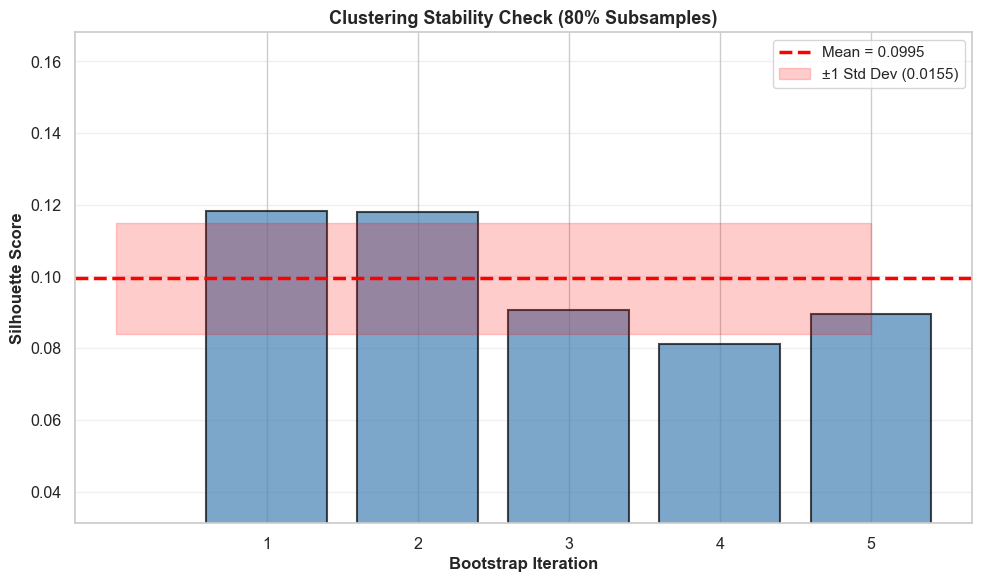

✅ Stability visualization complete.


In [51]:
# ── Visualize stability scores ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(range(1, 6), stability_scores, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=mean_stability, color='red', linestyle='--', linewidth=2.5, label=f'Mean = {mean_stability:.4f}')
ax.fill_between(
    range(0, 6),
    mean_stability - std_stability,
    mean_stability + std_stability,
    alpha=0.2,
    color='red',
    label=f'±1 Std Dev ({std_stability:.4f})'
)

ax.set_xlabel('Bootstrap Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax.set_title('Clustering Stability Check (80% Subsamples)', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='best')
ax.set_ylim(min(stability_scores) - 0.05, max(stability_scores) + 0.05)

plt.tight_layout()
plt.show()

print("✅ Stability visualization complete.")

---
## 12. Conclusion

### Summary of Findings

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **Optimal k** | 3 | Best-supported setting in this pipeline |
| **Silhouette Score** | 0.1182 | Weak-to-moderate separation |
| **Davies-Bouldin Index** | 2.3905 | Noticeable overlap between clusters |
| **Calinski-Harabasz** | 1313.9 | Meaningful global structure |
| **Stability (5 samples)** | Mean 0.0995 | Stable across subsamples |

### Cluster Profiles

1. **High Performers** (~46.5%): strongest academic profile.
2. **Average / Steady Learners** (~45.2%): moderate profile with improvement potential.
3. **At-Risk / Struggling Students** (~8.3%): lowest-performing group requiring priority support.

### Practical Implication

The model is suitable for early identification and targeted intervention, with the caveat that cluster boundaries are not sharply separated.

### Limitations and Future Work

- Results depend on selected features and preprocessing.
- The analysis is cross-sectional (single-time snapshot).
- Future comparison with Hierarchical Clustering, DBSCAN, or GMM may improve robustness.

---
**End of K-Means Clustering Analysis**

In [52]:
# ── Save results ──────────────────────────────────────────────────────────────
# Optional: Save the dataset with cluster assignments for further analysis

output_path = Path("../Data/processed/clustered_students.csv")
df.to_csv(output_path, index=False)

print(f"✅ Clustered dataset saved to: {output_path}")
print(f"   Columns: Original features + 'Cluster' assignment")

✅ Clustered dataset saved to: ..\Data\processed\clustered_students.csv
   Columns: Original features + 'Cluster' assignment
